# Spotify Song Success Predictor

## Project Description

This project aims to determine whether the audio properties of a song —
such as danceability, energy, key, loudness, mode, speechiness, acousticness,
instrumentalness, liveness, valence, tempo, and duration — can predict its
commercial success on Spotify, measured by its presence in the Spotify
Top 200 charts.

## Motivation

The music industry invests heavily in artist development and song promotion,
yet predicting a song's success remains largely subjective. By leveraging
Spotify's audio feature data alongside historical chart performance, this
project explores whether measurable acoustic properties alone carry enough
signal to anticipate a song's reach and popularity.


## Objective

**Global Success Classification**

Build a binary classification model to predict whether a song will reach
the Spotify Top 200 charts based solely on its audio properties and genre.
A song is considered successful if it appeared at least once in the Top 200
during the 2017-2021 observation window, and unsuccessful otherwise.


## Datasets

**Dataset 1 — 30,000 Spotify Songs**

- Source: Kaggle (joebeachcapital/30000-spotify-songs)
- Contains approximately 30,000 songs with detailed audio features extracted
  directly from the Spotify API, including danceability, energy, valence,
  tempo, and more. Songs span release dates from 1957 to 2020.

**Dataset 2 — Spotify Charts**

- Source: Kaggle (dhruvildave/spotify-charts)
- Contains over 26 million chart entry records from Spotify's Top 200 and
  Viral 50 charts across 69 regions, covering the period from January 2017
  to July 2021. Each record represents a song's appearance on a regional
  chart on a specific date.


## Methodology Overview

1. Both datasets are joined by Spotify track ID, extracted from the chart
   entry URLs in Dataset 2, ensuring an exact match without ambiguity.
2. Only Top 200 chart entries are considered, excluding Viral 50, as the
   Top 200 is a more standardized measure of commercial success based on
   stream counts.
3. Songs from Dataset 1 are filtered to the 2016–2021 window to ensure
   temporal alignment with the charts data. A start date of January 2016
   is used to account for songs released in late 2016 that may have
   charted in early 2017.
4. Duplicate entries caused by songs appearing across multiple playlists
   are removed by keeping one record per unique track ID.
5. Chart data is aggregated to one record per song with global metrics
   such as total chart appearances, total streams, average streams per
   appearance, number of regions reached, and best rank achieved.
6. Songs not found in any Top 200 chart are labeled as not_successful,
   under the assumption that their absence from the charts during the
   observation window reflects a lack of commercial traction on the
   platform.
7. A binary classification approach is adopted after an initial multiclass
   scheme (not_successful / moderately_successful / successful) was found
   to produce ambiguous class boundaries in the audio feature space and
   a more severe class imbalance.


## Limitations

- Songs released before 2017 are excluded regardless of their historical
  relevance, as chart data is only available from 2017 onward.
- The not_successful label is an approximation. A song with zero chart
  appearances may have underperformed on Spotify specifically while
  succeeding on other platforms, or may have failed to match during the
  join due to URL inconsistencies in the charts dataset.
- Audio features are static properties extracted at a single point in time
  and do not capture how a song evolves in listener perception over time.
- The model does not account for external factors such as marketing spend,
  artist popularity, or social media trends, which are known to influence
  chart performance significantly.
- The observation window covers 2017-2021, a period dominated by specific
  genres and cultural trends. Results may not generalize to other time
  periods or music markets.




## Data Preprocessing

### 1. Loading the Datasets

Both datasets are loaded from CSV files. Given the size of the charts
dataset (approximately 26 million records), no full in-memory operations
are performed on it beyond the necessary filtering and aggregation steps.

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn jupyter

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached argon2_cffi_bindings-25.1.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.4 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached rfc3339_validator-0.1.4-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached rf

In [5]:
import pandas as pd

In [6]:
# --- Load spotify_songs ---
songs = pd.read_csv("./spotify_songs.csv")
# --- Load spotify_charts ---
charts_dtypes = {
    'title':   'category',
    'rank':    'int8',
    'artist':  'category',
    'url':     'object',
    'region':  'category',
    'chart':   'category',
    'trend':   'category',
    'streams': 'float32',
}
charts = pd.read_csv(
    "./charts.csv",
    dtype=charts_dtypes,
    parse_dates=['date']
  )

In [7]:
print("Songs dataset shape: ", songs.shape)
print("Charts dataset shape: ", charts.shape)
songs.nunique()

Songs dataset shape:  (32833, 23)
Charts dataset shape:  (26173514, 9)


track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

### 2. Spotify Songs Dataset — Filtering and Deduplication

**Temporal filtering**

Songs released outside the 2017-2021 window are excluded to ensure
temporal alignment with the charts dataset.

In [8]:
# Convert release_date to date type
songs['track_album_release_date'] = pd.to_datetime(
    songs['track_album_release_date'],
    errors='coerce'
)

# Filter to get only the songs that we could know that they were in the charts
mask = (songs['track_album_release_date'] >= '2017-01-01') & \
       (songs['track_album_release_date'] <= '2021-07-31')

songs_filtered = songs[mask]
print(f"Filtered songs: {len(songs_filtered):,}")
print(f"Descarted songs: {len(songs) - len(songs_filtered):,}")

Filtered songs: 15,602
Descarted songs: 17,231


After filtering, the dataset is reduced from approximately 32,000 to
15,602 records.

In [9]:
songs_filtered.nunique()

track_id                    13096
track_name                  11613
track_artist                 6602
track_popularity              101
track_album_id              11623
track_album_name            10567
track_album_release_date      985
playlist_name                 359
playlist_id                   377
playlist_genre                  6
playlist_subgenre              24
danceability                  747
energy                        907
key                            12
loudness                     7017
mode                            2
speechiness                  1205
acousticness                 3057
instrumentalness             3579
liveness                     1374
valence                      1219
tempo                        8787
duration_ms                 10820
dtype: int64

**Deduplication and Feature selection**

The original dataset is structured around playlists, meaning the same
song can appear multiple times across different playlists or genres.
Since audio features are intrinsic properties of the track and are
identical across duplicate entries, duplicates are removed by keeping
only the first occurrence of each unique track ID.

Also, only columns relevant to the model are retained. Identifiers such as
album name, playlist name, and playlist ID are dropped. Track popularity
is intentionally excluded to avoid data leakage, as it is a Spotify-
computed metric that already reflects listener engagement and would make
the classification task trivial.

Retained columns:

- track_id (join key, not a model feature)
- danceability, energy, key, loudness, mode, speechiness, acousticness,
  instrumentalness, liveness, valence, tempo, duration_ms (audio features)
- playlist_genre, playlist_subgenre (genre context)

In [10]:
important_features = [
    "track_id",

    # Audio Features
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",

    # Categorical Features
    "playlist_genre",
    "playlist_subgenre",
]
songs_unique = (
    songs_filtered[important_features]
    .drop_duplicates(subset="track_id", keep="first")
)
songs_unique.shape

(13096, 15)

After deduplication, the dataset contains 13,096 unique songs.

### 3. Charts Dataset — Filtering and Aggregation

**Chart type filtering**

Only Top 200 chart entries are kept. Viral 50 entries are excluded, as
the Top 200 is a more standardized and widely recognized measure of
commercial success based on stream counts rather than virality trends.

In [11]:
# Filter to get only the top200 songs
charts_filtered = charts[
    (charts["rank"] <= 200) &
    (charts["chart"] == "top200")
].copy()
print(charts_filtered["chart"].unique())

['top200']
Categories (2, str): ['top200', 'viral50']


In [12]:
charts_filtered.nunique()

title       91225
rank          200
date         1823
artist      40177
url        118835
region         69
chart           1
trend           4
streams    788013
dtype: int64

**Track ID extraction**

The charts dataset does not contain a direct track ID column. The ID is
extracted from the Spotify track URL using a regular expression:

```
track_id = url.str.extract(r"track/([a-zA-Z0-9]+)")
```

In [13]:
# --- Extract track_id from the Spotify URL ---
# URL format: https://open.spotify.com/track/<track_id>
charts_filtered['track_id'] = charts_filtered['url'].str.split('/').str[-1]

**Aggregation**

Chart entries are grouped by track ID to produce one record
per song, with the following aggregated metrics:

- n_in_top200: total number of chart appearances
- total_streams: sum of streams accumulated
- avg_streams: average streams per chart appearance
- best_rank: best (minimum) rank achieved

In [14]:
charts_aggregated = (
    charts_filtered
    .groupby(["track_id"], observed=True)
    .agg(
        n_in_top200=("track_id", "size"),
        total_streams=("streams", "sum"),
        avg_streams=("streams", "mean"),
        best_rank=("rank", "min"),
    )
    .reset_index()
)

### 4. Base Dataset Construction

The filtered Spotify dataset and the aggregated charts dataset are joined
using a left join on track_id, preserving all 13,096 unique songs
regardless of whether they appeared in any chart.

Songs with no chart appearances receive zero values for all chart metrics.

In [15]:
# Build a dataset with stats information
songs_curated_base = songs_unique.merge(charts_aggregated, on="track_id", how="left")

print("Shape of the curated dataset: ", songs_curated_base.shape)

# Set 0 to all the songs that are not in charts
songs_curated_base[["n_in_top200", "total_streams", "avg_streams", "best_rank"]] = (
    songs_curated_base[["n_in_top200", "total_streams", "avg_streams", "best_rank"]]
    .fillna(0)
)

Shape of the curated dataset:  (13096, 19)


In [16]:
# Validate there are no null values so that the dataset is completely curated
songs_curated_base.isna().sum()

track_id             0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
playlist_genre       0
playlist_subgenre    0
n_in_top200          0
total_streams        0
avg_streams          0
best_rank            0
dtype: int64

In [17]:
songs_curated_base.head()

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,n_in_top200,total_streams,avg_streams,best_rank
0,6f807x0ima9a1j3VPbc7VN,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,pop,dance pop,0.0,0.0,0.000000,0.0
1,0r7CVbZTWZgbTCYdfa2P31,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,pop,dance pop,9.0,31511.0,3501.222168,-95.0
2,1z1Hg7Vb0AhHDiEmnDE79l,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,pop,dance pop,0.0,0.0,0.000000,0.0
3,75FpbthrwQmzHlBJLuGdC7,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,pop,dance pop,0.0,0.0,0.000000,0.0
4,1e8PAfcKUYoKkxPhrHqw4x,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,pop,dance pop,1.0,7308.0,7308.000000,126.0


The resulting base dataset contains one record per song and
serves as the single source of truth for the objective: derives a global view by aggregating across regions.

In [18]:
cols_audio = [
    "track_id", "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms", "playlist_genre", "playlist_subgenre"
]

songs_global = (
    songs_curated_base
    .groupby("track_id", observed=True)
    .agg(
        n_in_top200=("n_in_top200", "sum"),
        total_streams=("total_streams", "sum"),
        avg_streams=("avg_streams", "mean"),
        best_rank=("best_rank", "min"),

        # As these columns are the same, we take the first
        danceability=("danceability", "first"),
        energy=("energy", "first"),
        key=("key", "first"),
        loudness=("loudness", "first"),
        mode=("mode", "first"),
        speechiness=("speechiness", "first"),
        acousticness=("acousticness", "first"),
        instrumentalness=("instrumentalness", "first"),
        liveness=("liveness", "first"),
        valence=("valence", "first"),
        tempo=("tempo", "first"),
        duration_ms=("duration_ms", "first"),
        playlist_genre=("playlist_genre", "first"),
        playlist_subgenre=("playlist_subgenre", "first"),
    )
    .reset_index()
)

## Class Definition

To define the success labels in an objective and data-driven manner,
songs were first separated into two groups: those that appeared at least
once in the Spotify Top 200 charts (charted songs), and those that did
not (uncharted songs).

In [19]:
songs_charted = songs_global[songs_global["n_in_top200"] > 0]
songs_uncharted = songs_global[songs_global["n_in_top200"] == 0]

print(f"Charted Songs in top200: {len(songs_charted)}")
print(f"Uncharted songs: {len(songs_uncharted)}")
print(f"Percentage of charted songs: {len(songs_charted) / len(songs_global) * 100:.1f}%")

Charted Songs in top200: 3561
Uncharted songs: 9535
Percentage of charted songs: 27.2%


Among the 13,096 unique songs in the dataset, 3,561 (27.2%) appeared in
the Top 200 at least once, while 9,535 (72.8%) had no chart appearances.

### Initial Approach: Multiclass Classification

An initial multiclass classification scheme was considered, dividing songs
into three categories based on their number of Top 200 chart appearances.

In [20]:
print("\n--- n_in_top200 percentiles ---")
for p in [25, 50, 75, 90]:
    val = songs_charted["n_in_top200"].quantile(p/100)
    print(f"  P{p}: {val:.0f}")

print("\n--- total_streams percentiles ---")
for p in [25, 50, 75, 90]:
    val = songs_charted["total_streams"].quantile(p/100)
    print(f"  P{p}: {val:,.0f}")


--- n_in_top200 percentiles ---
  P25: 21
  P50: 177
  P75: 1131
  P90: 4990

--- total_streams percentiles ---
  P25: 562,026
  P50: 6,093,086
  P75: 53,630,560
  P90: 308,708,288


In [21]:
def assign_label(row):
    if row["n_in_top200"] == 0:
        return "not_successful"
    elif row["n_in_top200"] <= 177:
        return "moderately_successful"
    else:
        return "successful"

songs_global["success_label"] = songs_global.apply(assign_label, axis=1)

print(songs_global["success_label"].value_counts())
print(songs_global["success_label"].value_counts(normalize=True).mul(100).round(1))

success_label
not_successful           9535
moderately_successful    1785
successful               1776
Name: count, dtype: int64
success_label
not_successful           72.8
moderately_successful    13.6
successful               13.6
Name: proportion, dtype: float64


Among the 3,561 charted songs, the median number of appearances (P50 = 177)
was used as the boundary between moderately successful and successful,
producing the following distribution:

- Not Successful: 9,535 songs (72.8%)
- Moderately Successful: 1,785 songs (13.6%)
- Successful: 1,776 songs (13.6%)

While the boundary between moderately successful and successful was
balanced by design, the overall class distribution revealed a significant
imbalance, with not_successful representing nearly 73% of the dataset.
Furthermore, preliminary model evaluation showed that the boundary between
moderately_successful and successful was not well-supported by the audio
feature space, as both classes exhibited very similar audio profiles,
leading to frequent misclassifications between them and a macro F1-score
of only 0.51.

### Final Approach: Binary Classification

Based on these findings, the classification scheme was simplified to a
binary problem. A song is labeled successful if it appeared at least once
in the Spotify Top 200 chart, and not_successful otherwise. This threshold
is objective and intuitive: any appearance in the Top 200, regardless of
rank or number of weeks, represents measurable commercial traction on the
platform.

The resulting class distribution is:

- Not Successful: 9,535 songs (72.8%)
- Successful: 3,561 songs (27.2%)

In [22]:
songs_global["success_label"] = songs_global["n_in_top200"].apply(
    lambda x: "successful" if x > 0 else "not_successful"
)

print(songs_global["success_label"].value_counts())
print(songs_global["success_label"].value_counts(normalize=True).mul(100).round(1))

success_label
not_successful    9535
successful        3561
Name: count, dtype: int64
success_label
not_successful    72.8
successful        27.2
Name: proportion, dtype: float64


This approach reduces the class imbalance ratio from approximately 5.3:1
(in the three-class scheme) to 2.7:1, making the problem more tractable
while preserving a meaningful and defensible definition of success.

## Exploratory Data Analysis

### Class Distribution

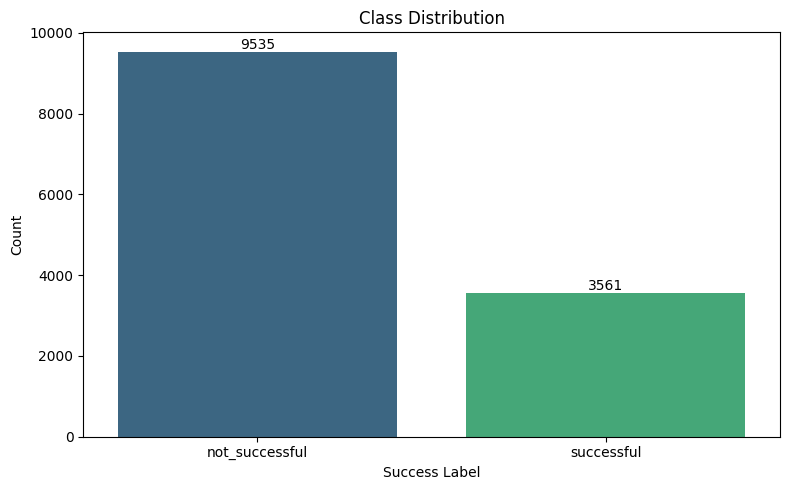

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=songs_global, x="success_label",
                   order=["not_successful", "successful"],
                   hue="success_label",
                   palette="viridis",
                   legend=False)
plt.title("Class Distribution")
plt.xlabel("Success Label")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

The dataset presents a class imbalance of approximately 2.7:1, with
not_successful representing 72.8% of all songs and successful representing
27.2%. This imbalance was addressed in the data preparation stage through
a combined undersampling and oversampling strategy.

### Audio Feature Distribution by Class

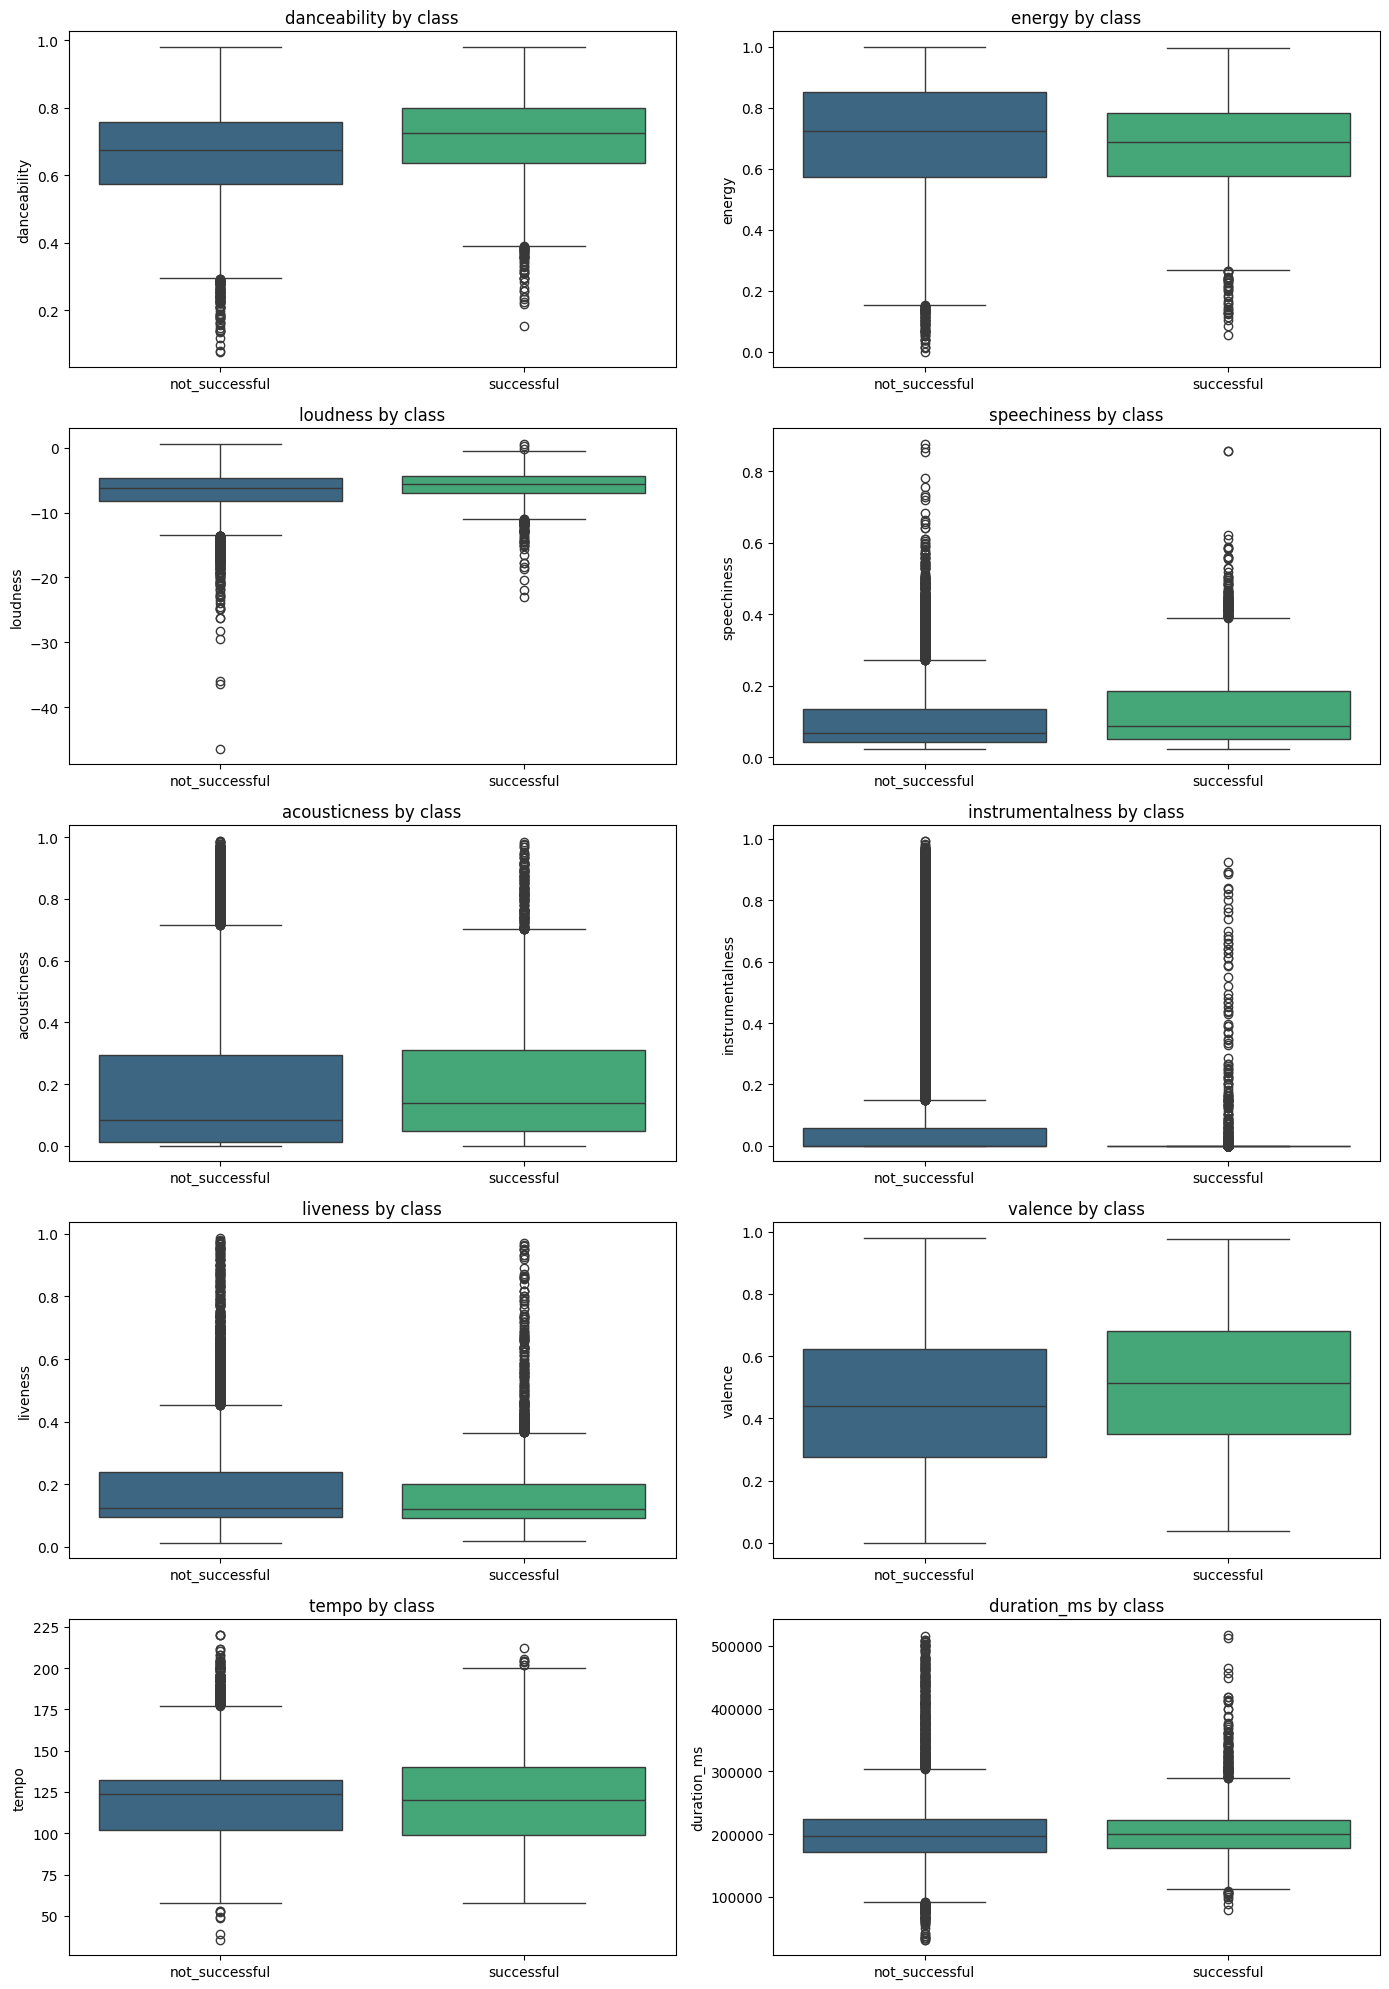

In [24]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.boxplot(
        data=songs_global,
        x="success_label",
        hue="success_label",
        y=feature,
        order=["not_successful", "successful"],
        palette="viridis",
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by class")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

Boxplot analysis of audio features across the two classes revealed the
following patterns:

- **Danceability**: Successful songs show a noticeably higher median
  danceability, suggesting that more rhythmically engaging songs tend to
  perform better on charts.
- **Valence**: Successful songs tend to have higher valence values,
  indicating that emotionally positive songs are more prevalent in the
  Top 200.
- **Loudness**: Successful songs are consistently louder, reflecting the
  high-production standards typical of commercially released music.
- **Speechiness**: Successful songs show a wider range of speechiness
  values, suggesting that both low and high vocal content can be
  compatible with chart success.
- **Acousticness and Instrumentalness**: Unsuccessful songs show higher
  variance in both features, while successful songs tend to cluster at
  lower values, confirming that produced, vocal-driven songs dominate
  the charts.
- **Energy, tempo, duration_ms, liveness**: These features show
  significant overlap between classes, suggesting limited individual
  discriminative power.

### Feature Correlation Analysis

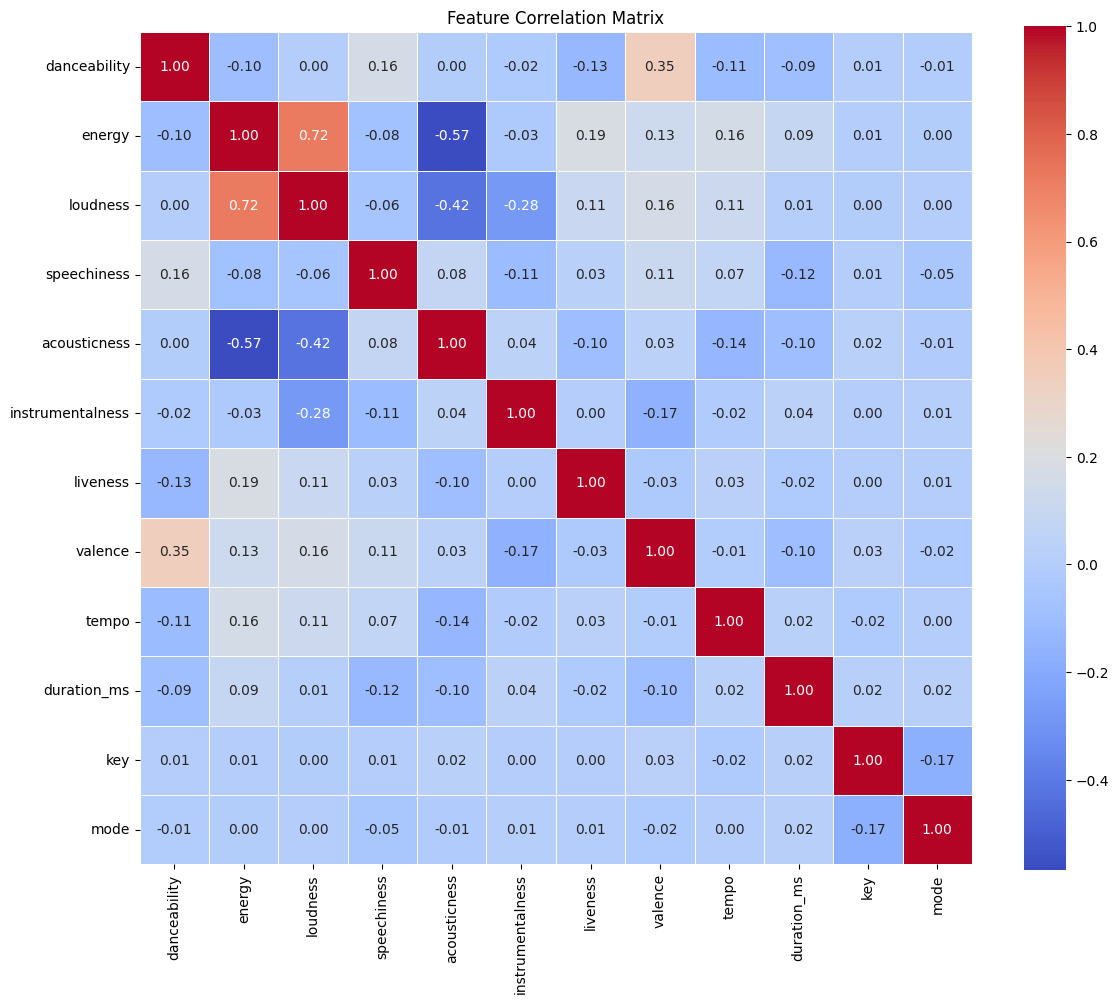

In [25]:
plt.figure(figsize=(12, 10))
cols_corr = audio_features + ["key", "mode"]
corr_matrix = songs_global[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix revealed two notable relationships among audio
features:

- **Energy and loudness (r = 0.72)**: Strong positive correlation, as
  louder songs tend to be more energetic. These features carry partially
  redundant information.
- **Energy and acousticness (r = -0.57)**: Strong negative correlation,
  consistent with the expectation that high-energy songs are rarely
  acoustic.
- **Danceability and valence (r = 0.35)**: Moderate positive correlation,
  suggesting that danceable songs tend to have a more positive emotional
  tone.

All remaining feature pairs showed low correlations, indicating that most
features contribute independent information to the model.

### Genre Distribution by Class

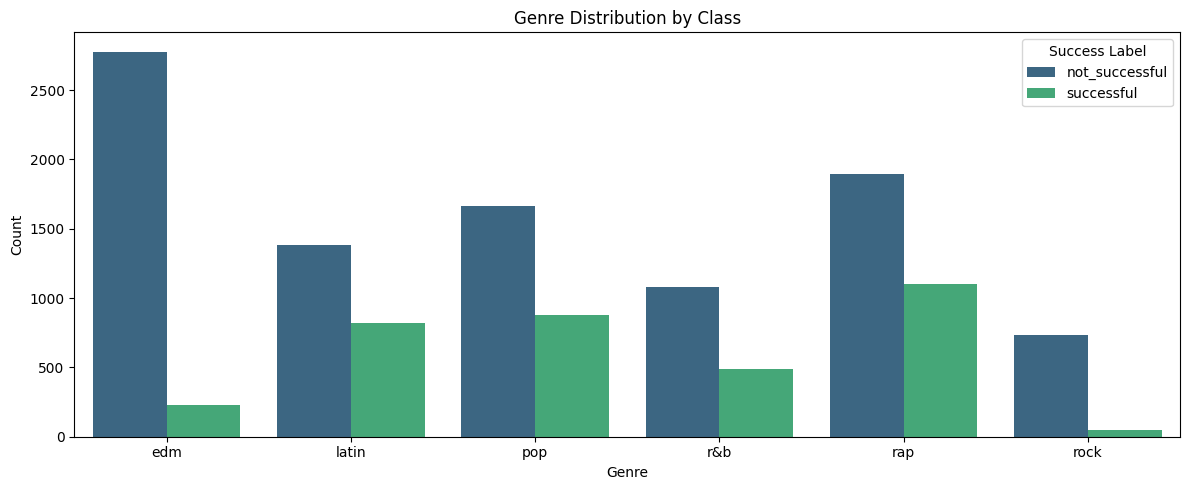

In [26]:
plt.figure(figsize=(12, 5))
genre_class = (
    songs_global.groupby(["playlist_genre", "success_label"])
    .size()
    .reset_index(name="count")
)
sns.barplot(data=genre_class, x="playlist_genre", y="count",
            hue="success_label", palette="viridis")
plt.title("Genre Distribution by Class")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.legend(title="Success Label")
plt.tight_layout()
plt.show()

Analysis of playlist genres revealed meaningful differences in success
rates across genres:

- **Rap** showed the highest proportion of successful songs relative to
  its total count, with a near 1:2 ratio of successful to not_successful
  songs.
- **Latin and Pop** also showed strong success rates, consistent with
  their dominance in global streaming charts during the 2016–2021 period.
- **EDM** had the lowest success rate proportionally, with approximately
  one successful song for every eleven not_successful ones.
- **Rock** showed almost no representation in the successful class,
  reflecting the genre's limited presence in mainstream streaming charts
  during the observation window.

## Data Preparation

### Feature Selection

The following features were selected as model inputs, excluding track
identifiers, album metadata, playlist identifiers, and track popularity
to prevent data leakage:

Audio features: danceability, energy, key, loudness, mode, speechiness,
acousticness, instrumentalness, liveness, valence, tempo, duration_ms.
Categorical features: playlist_genre, playlist_subgenre.

In [28]:
features = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms",
    "playlist_genre", "playlist_subgenre"
]

X = songs_global[features].copy()
y = songs_global["success_label"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (13096, 14)
y shape: (13096,)


### Encoding

One-hot encoding was applied to playlist_genre and playlist_subgenre
using pd.get_dummies, producing 6 and 24 binary columns respectively,
for a total of 42 input features. The key and mode features were retained
as numeric values, as key represents the 12 chromatic musical notes and
mode is already binary (0 = minor, 1 = major).

In [29]:
X = pd.get_dummies(X, columns=["playlist_genre", "playlist_subgenre"])

print(f"Shape of X after one-hot encoding: {X.shape}")
print(X.columns.tolist())

Shape of X after one-hot encoding: (13096, 42)
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_genre_edm', 'playlist_genre_latin', 'playlist_genre_pop', 'playlist_genre_r&b', 'playlist_genre_rap', 'playlist_genre_rock', 'playlist_subgenre_album rock', 'playlist_subgenre_big room', 'playlist_subgenre_classic rock', 'playlist_subgenre_dance pop', 'playlist_subgenre_electro house', 'playlist_subgenre_electropop', 'playlist_subgenre_gangster rap', 'playlist_subgenre_hard rock', 'playlist_subgenre_hip hop', 'playlist_subgenre_hip pop', 'playlist_subgenre_indie poptimism', 'playlist_subgenre_latin hip hop', 'playlist_subgenre_latin pop', 'playlist_subgenre_neo soul', 'playlist_subgenre_new jack swing', 'playlist_subgenre_permanent wave', 'playlist_subgenre_pop edm', 'playlist_subgenre_post-teen pop', 'playlist_subgenre_progressive electro house', 'playlist_subgenre_reggaeton', 'p

The target variable
success_label was encoded using LabelEncoder, mapping not_successful → 0
and successful → 1.

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le_label = LabelEncoder()
y_encoded = le_label.fit_transform(y)

print("\nEncoded classes:", dict(zip(le_label.classes_,
                                        le_label.transform(le_label.classes_))))


Encoded classes: {'not_successful': np.int64(0), 'successful': np.int64(1)}


### Train/Test Split

The dataset was split into 80% training (10,476 samples) and 20% test
(2,620 samples) sets using stratified sampling to preserve the original
class distribution in both subsets. The test set is never modified during
any balancing or scaling step, maintaining the real-world class
distribution for evaluation.

In [31]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

for split, y_split in [("Train", y_train), ("Test", y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"\n{split} class distribution:")
    for cls, count in zip(le_label.classes_, counts):
        print(f"  {cls}: {count} ({count/len(y_split)*100:.1f}%)")


Train size: (10476, 42)
Test size: (2620, 42)

Train class distribution:
  not_successful: 7627 (72.8%)
  successful: 2849 (27.2%)

Test class distribution:
  not_successful: 1908 (72.8%)
  successful: 712 (27.2%)


### Normalization

StandardScaler was applied to normalize all features to zero mean and
unit variance. The scaler was fitted exclusively on the training set and
then applied to the test set to prevent data leakage.

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
print(list(zip(le_label.classes_, le_label.transform(le_label.classes_))))

[('not_successful', np.int64(0)), ('successful', np.int64(1))]


### Class Balancing

To address the class imbalance, a combined sampling strategy was applied
exclusively on the training set:

1. **Random Undersampling**: The not_successful class was reduced from
   7,627 to 4,000 samples to limit the dominance of the majority class
   while retaining a substantial number of real examples.

In [34]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Undersampling so that we balance the not_successful songs
undersample = RandomUnderSampler(
    sampling_strategy={
        0: 4000
    },
    random_state=42
)

X_train_under, y_train_under = undersample.fit_resample(X_train_scaled, y_train)

print("After undersampling:")
unique, counts = np.unique(y_train_under, return_counts=True)
for cls, count in zip(le_label.classes_, counts):
    print(f"  {cls}: {count}")

After undersampling:
  not_successful: 4000
  successful: 2849


2. **SMOTE (Synthetic Minority Oversampling Technique)**: Synthetic
   samples were generated for the successful class until both classes
   reached 4,000 samples each.

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_under, y_train_under)

print(f"\nBefore de SMOTE: {X_train_scaled.shape}")
print(f"After de SMOTE: {X_train_balanced.shape}")

print("\nClasses after SMOTE:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for cls, count in zip(le_label.classes_, counts):
    print(f"  {cls}: {count}")


Before de SMOTE: (10476, 42)
After de SMOTE: (8000, 42)

Classes after SMOTE:
  not_successful: 4000
  successful: 4000


The final balanced training set contains 8,000 samples with equal class
distribution. This combined approach minimizes the number of synthetic
samples compared to applying SMOTE alone, preserving a higher proportion
of real data in the training set.

## Model Training and Evaluation

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

### Baseline — Logistic Regression

A logistic regression model was trained as a baseline to establish a
reference performance level.

In [37]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_balanced, y_train_balanced)

y_pred_lr = lr.predict(X_test_scaled)

print("=" * 50)
print("BASELINE — LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=le_label.classes_))

BASELINE — LOGISTIC REGRESSION
                precision    recall  f1-score   support

not_successful       0.90      0.69      0.78      1908
    successful       0.49      0.80      0.60       712

      accuracy                           0.72      2620
     macro avg       0.69      0.74      0.69      2620
  weighted avg       0.79      0.72      0.73      2620



The
model achieved an overall accuracy of 72% and a weighted F1-score of
0.73. The AUC-ROC score was 0.8036, already exceeding the 0.80 threshold
considered strong for binary classification problems, which indicates
that the relationship between audio features and chart success has a
meaningful linear component.

### Main Model — Random Forest

A Random Forest classifier with 200 estimators and a maximum depth of 15
was trained on the balanced dataset.

In [38]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf.predict(X_test_scaled)

print("=" * 50)
print("MAIN MODEL — RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=le_label.classes_))

MAIN MODEL — RANDOM FOREST
                precision    recall  f1-score   support

not_successful       0.91      0.70      0.79      1908
    successful       0.50      0.80      0.62       712

      accuracy                           0.73      2620
     macro avg       0.70      0.75      0.70      2620
  weighted avg       0.80      0.73      0.74      2620



The model achieved an overall
accuracy of 72% and a weighted F1-score of 0.74, with an AUC-ROC of
0.8161, outperforming the baseline. The F1-score for the successful class
reached 0.61, reflecting the inherent difficulty of predicting chart
success from audio features alone.

### Best Model — XGBoost



An XGBoost classifier with 300 estimators, a maximum depth of 6, and a
learning rate of 0.1 was trained on the balanced dataset.

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb.predict(X_test_scaled)

print("=" * 50)
print(" MODEL — XGBoost")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=le_label.classes_))

 MODEL — XGBoost
                precision    recall  f1-score   support

not_successful       0.88      0.74      0.81      1908
    successful       0.52      0.74      0.61       712

      accuracy                           0.74      2620
     macro avg       0.70      0.74      0.71      2620
  weighted avg       0.78      0.74      0.75      2620



XGBoost
achieved the best overall performance with an accuracy of 74%, a weighted
F1-score of 0.75, and an AUC-ROC of 0.8154. The F1-score for
not_successful reached 0.81, while successful achieved 0.61.



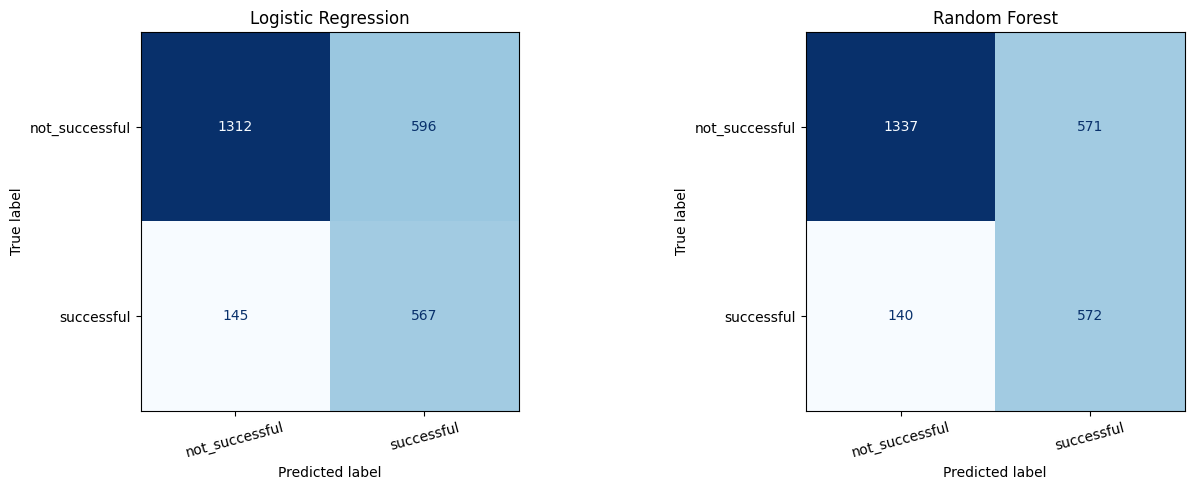

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=le_label.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    ax.set_xticklabels(le_label.classes_, rotation=15)

plt.tight_layout()
plt.show()

The confusion matrix shows that the most frequent error is classifying
not_successful songs as successful (false positives), which is expected
given the audio similarity between many uncharted and charted songs and
the influence of non-audio factors on chart performance.

In [41]:
y_prob_lr = lr.predict_proba(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)

auc_lr = roc_auc_score(y_test, y_prob_lr[:, 1])
auc_rf = roc_auc_score(y_test, y_prob_rf[:, 1])
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:, 1])

print(f"AUC-ROC Logistic Regression: {auc_lr:.4f}")
print(f"AUC-ROC Random Forest:       {auc_rf:.4f}")
print(f"AUC-ROC XGBoost:             {auc_xgb:.4f}")

AUC-ROC Logistic Regression: 0.8036
AUC-ROC Random Forest:       0.8167
AUC-ROC XGBoost:             0.8154


### Feature Importance

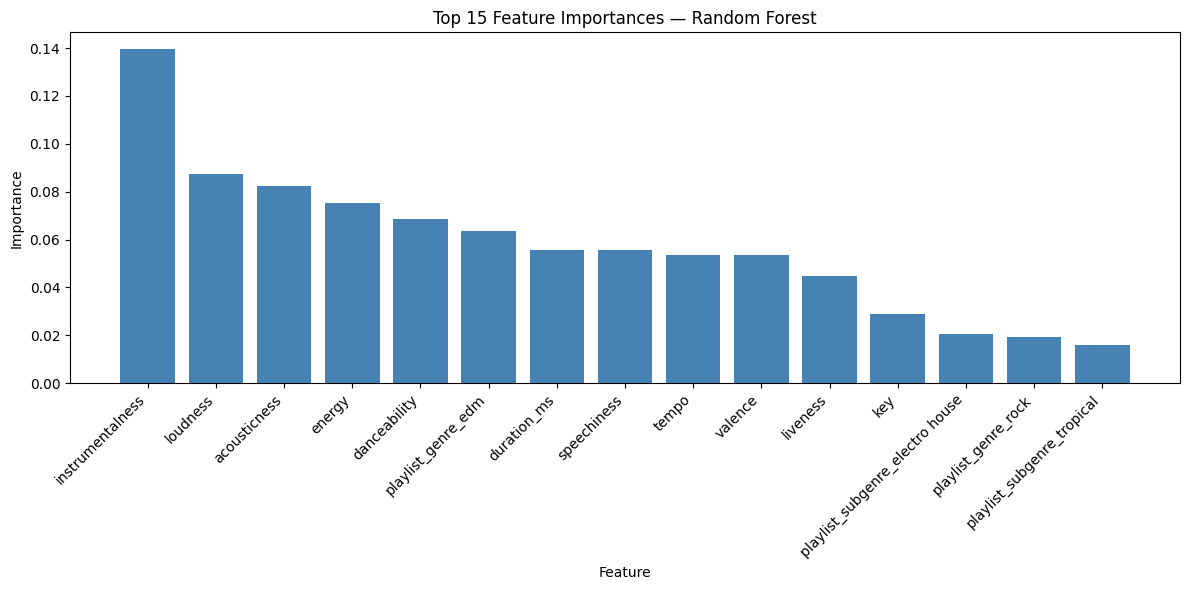

In [42]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = importances.argsort()[::-1][:15]  # top 15

plt.figure(figsize=(12, 6))
plt.bar(range(15), importances[indices], color="steelblue")
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Analysis of Random Forest feature importances identified instrumentalness
as the single most predictive feature (importance = 0.14), confirming
that the presence of vocals is a strong indicator of chart performance.
This is followed by loudness (0.086), acousticness (0.083), energy
(0.076), and danceability (0.069).

The relatively flat importance distribution after instrumentalness
indicates that the model relies on a combination of audio properties
rather than a single dominant feature. Genre features such as
playlist_genre_edm contributed notably, confirming that genre context
adds predictive signal beyond raw audio characteristics. Key and mode
ranked among the least important features, consistent with the
exploratory analysis findings.

In [46]:
!pip install requests essentia-tensorflow yt_dlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 9.7 MB/s  0:00:00m 9.6 MB/s eta 0:00:01


In [54]:
import requests
import base64
import tempfile
import os
import numpy as np
import essentia.standard as es
import yt_dlp


def download_audio_youtube(track_name, artist_name):
    query = f"{track_name} {artist_name} official audio"
    tmp_dir = tempfile.mkdtemp()
    tmp_path = os.path.join(tmp_dir, "audio.mp3")

    ydl_opts = {
        "format": "bestaudio/best",
        "outtmpl": tmp_path.replace(".mp3", ""),
        "quiet": True,
        "no_warnings": True,
        "postprocessors": [{
            "key": "FFmpegExtractAudio",
            "preferredcodec": "mp3",
            "preferredquality": "192",
        }],
        "default_search": "ytsearch1",
        "noplaylist": True,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([query])

    return tmp_path


# ─── Spotify Auth ────────────────────────────────────────────────
def get_spotify_token(client_id, client_secret):
    credentials = base64.b64encode(f"{client_id}:{client_secret}".encode()).decode()
    res = requests.post(
        "https://accounts.spotify.com/api/token",
        headers={"Authorization": f"Basic {credentials}",
                 "Content-Type": "application/x-www-form-urlencoded"},
        data={"grant_type": "client_credentials"}
    )
    res.raise_for_status()
    return res.json()["access_token"]


# ─── Spotify Search ──────────────────────────────────────────────
def search_track(token, track_name, limit=5):
    res = requests.get(
        "https://api.spotify.com/v1/search",
        headers={"Authorization": f"Bearer {token}"},
        params={"q": track_name, "type": "track", "limit": limit, "market": "MX"}
    )
    res.raise_for_status()
    return [
        {
            "id":         t["id"],
            "name":     t["name"],
            "artist":    ", ".join(a["name"] for a in t["artists"]),
            "album":      t["album"]["name"],
            "duration_ms": t["duration_ms"],
        }
        for t in res.json()["tracks"]["items"]
    ]


# ─── Essentia Feature Extraction ─────────────────────────────────
def extract_features(track_name, artist_name):
    tmp_path = download_audio_youtube(track_name, artist_name)

    try:
        # 1. Load audio
        audio = es.MonoLoader(filename=tmp_path, sampleRate=44100)()

        # 2. Tempo
        rhythm = es.RhythmExtractor2013(method="multifeature")
        tempo, _, _, _, _ = rhythm(audio)

        # 3. Key y Mode
        key_str, scale, _ = es.KeyExtractor()(audio)
        key_map = {"C":0,"C#":1,"D":2,"D#":3,"E":4,"F":5,
                   "F#":6,"G":7,"G#":8,"A":9,"A#":10,"B":11}
        key  = key_map.get(key_str, -1)
        mode = 1 if scale == "major" else 0

        # 4. Loudness
        loudness = float(es.Loudness()(audio))

        # 5. Energy
        energy_norm = min(float(es.Energy()(audio)) / 1e7, 1.0)

        # 6. Spectral features
        w        = es.Windowing(type="hann")
        spectrum = es.Spectrum()
        centroid = es.SpectralCentroidTime()
        rolloff  = es.RollOff()
        flux     = es.Flux()

        centroids, rolloffs, fluxes = [], [], []
        for frame in es.FrameGenerator(audio, frameSize=2048, hopSize=512):
            spec = spectrum(w(frame))
            centroids.append(centroid(frame))
            rolloffs.append(rolloff(spec))
            fluxes.append(flux(spec))

        mean_centroid = float(np.mean(centroids))
        mean_rolloff  = float(np.mean(rolloffs))
        mean_flux     = float(np.mean(fluxes))

        # 7. Proxies
        danceability_proxy     = min(float(es.Danceability()(audio)[0]), 1.0)
        speechiness_proxy      = min(mean_centroid / 4000, 1.0)
        acousticness_proxy     = max(0.0, 1.0 - mean_rolloff)
        instrumentalness_proxy = max(0.0, 1.0 - speechiness_proxy * 2)
        liveness_proxy         = min(mean_flux / 50, 1.0)
        valence_proxy          = min((mean_centroid / 8000 + energy_norm) / 2, 1.0)

        return pd.DataFrame([{
            "danceability":     round(danceability_proxy, 4),
            "energy":           round(energy_norm, 4),
            "key":              key,
            "loudness":         round(loudness, 4),
            "mode":             mode,
            "speechiness":      round(speechiness_proxy, 4),
            "acousticness":     round(acousticness_proxy, 4),
            "instrumentalness": round(instrumentalness_proxy, 4),
            "liveness":         round(liveness_proxy, 4),
            "valence":          round(valence_proxy, 4),
            "tempo":            round(float(tempo), 4),
            "duration_ms":      round(len(audio) / 44100 * 1000, 2),
            "playlist_genre":   "unknown",
            "playlist_subgenre":"unknown",
        }])
    finally:
        os.unlink(tmp_path)


# ─── Main ─────────────────────────────────────────────────────────
def main():
    SPOTIFY_CLIENT_ID     = "e5d996ecc768462288237c4d0bd40214"
    SPOTIFY_CLIENT_SECRET = "b30ce8127e86424689a5d260f8292fb0"

    token   = get_spotify_token(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)
    query   = input("🔍 Song: ")
    results = search_track(token, query)

    print(f"\n{'#':<3} {'Song':<35} {'Artist':<25} {'Album'}")
    print("-" * 80)
    for i, t in enumerate(results, 1):
        print(f"{i:<3} {t['name'][:34]:<35} {t['artist'][:24]:<25} {t['album'][:20]}")

    choice = int(input("\nIt is one of these? (1-5): ")) - 1
    track  = results[choice]

    print(f"\n⏳ Searching and analizing '{track['name']}' de {track['artist']}...")
    features = extract_features(track["name"], track["artist"])

    print("\n🎵 Audio Features:")
    print("-" * 35)
    for k, v in features.items():
        print(f"  {k:<20}: {v}")

    song_encoded = pd.get_dummies(features, columns=["playlist_genre", "playlist_subgenre"])
    song_encoded = song_encoded.reindex(columns=X.columns, fill_value=0)
    song_scaled = scaler.transform(song_encoded)
    prediction = rf.predict(song_scaled)
    print(f"\n🎯 Prediction: {'Succesful ✅' if prediction else 'Unsuccesful ❌'}")

if __name__ == "__main__":
    main()


#   Song                                Artist                    Album
--------------------------------------------------------------------------------
1   Blinding Lights                     The Weeknd                After Hours
2   Blinding Lights                     The Weeknd                Blinding Lights
3   Save Your Tears                     The Weeknd                After Hours
4   Blinding Lights (with ROSALÍA) - R  The Weeknd, ROSALÍA       Blinding Lights (Rem
5   Blinding Lights - Live              The Weeknd                Live At SoFi Stadium

⏳ Searching and analizing 'Blinding Lights' de The Weeknd...
                                                         
🎵 Audio Features:
-----------------------------------
  danceability        : 0    1.0
Name: danceability, dtype: float64
  energy              : 0    0.1107
Name: energy, dtype: float64
  key                 : 0    5
Name: key, dtype: int64
  loudness            : 0    11206.2461
Name: loudness, dtype: float64
 